# Machine Learning-Based Network Intrusion Detection System (NIDS)

## Models Used:
- Random Forest (Baseline)
- XGBoost (Main Model)
- Deep Neural Network (DNN)

## Evaluation:
- Accuracy, Precision, Recall, F1-score
- ROC Curve, AUC
- Confusion Matrix
- Training vs Validation Curve
- Model Complexity Analysis

### Import Essential Libraries

In [43]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

### Load Dataset

In [44]:
# Load NSL-KDD dataset
train = pd.read_csv("../nsl-kdd/KDDTrain+.txt", header=None)
test = pd.read_csv("../nsl-kdd/KDDTest+.txt", header=None)

### Add Column name

In [45]:
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train.columns = columns
test.columns = columns

In [46]:
train['label'] = train['label'].replace(
    ['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm'], 'Dos'
)

train['label'] = train['label'].replace(
    ['ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock','xsnoop'], 'R2L'
)

train['label'] = train['label'].replace(
    ['ipsweep','mscan','nmap','portsweep','saint','satan'], 'Probe'
)

train['label'] = train['label'].replace(
    ['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'], 'U2R'
)

In [47]:
test['label'] = test['label'].replace(
    ['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm'], 'Dos'
)

test['label'] = test['label'].replace(
    ['ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock','xsnoop'], 'R2L'
)

test['label'] = test['label'].replace(
    ['ipsweep','mscan','nmap','portsweep','saint','satan'], 'Probe'
)

test['label'] = test['label'].replace(
    ['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'], 'U2R'
)

In [48]:
train_orginal = train.copy()
test_orginal = test.copy()

In [49]:
# changing attack labels into two categories 'normal' and 'abnormal'
train['label'] = train['label'].replace(['Dos','R2L','Probe','U2R'], 'abnormal')
train['label'] = train['label'].replace(['normal'], 'normal')

test['label'] = test['label'].replace(['Dos','R2L','Probe','U2R'], 'abnormal')
test['label'] = test['label'].replace(['normal'], 'normal')

In [50]:
# map attack labels into two categories 'normal' and 'abnormal'
train['label'] = train['label'].map({'normal': 0, 'abnormal': 1})
test['label'] = test['label'].map({'normal': 0, 'abnormal': 1})

### Encode categorial features

In [51]:
categorical_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()

for col in categorical_cols:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

### Split the features and labels

In [52]:
X_train = train.drop(['label', 'difficulty'], axis=1)
y_train = train['label']

X_test = test.drop(['label', 'difficulty'], axis=1)
y_test = test['label']

### Feature Scaling (for DNN)

In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### MODEL 1: RANDOM FOREST

In [54]:
start = time.time()

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf.fit(X_train, y_train)

rf_time = time.time() - start

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

### MODEL 2: XGBOOST

In [55]:
start = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_time = time.time() - start

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

### MODEL 3: DNN

In [56]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()

history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2
)

dnn_time = time.time() - start

dnn_prob = model.predict(X_test_scaled).ravel()
dnn_pred = (dnn_prob > 0.5).astype(int)

f:\miniconda\envs\ml_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9678 - loss: 0.0891 - val_accuracy: 0.9896 - val_loss: 0.0321
Epoch 2/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9847 - loss: 0.0402 - val_accuracy: 0.9903 - val_loss: 0.0263
Epoch 3/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9866 - loss: 0.0349 - val_accuracy: 0.9911 - val_loss: 0.0244
Epoch 4/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9883 - loss: 0.0309 - val_accuracy: 0.9915 - val_loss: 0.0236
Epoch 5/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9893 - loss: 0.0286 - val_accuracy: 0.9916 - val_loss: 0.0212
Epoch 6/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9901 - loss: 0.0267 - val_accuracy: 0.9936 - val_loss: 0.0202
Epoch 7/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9898 - loss: 0.0264 - val_accuracy: 0.9929 - val_loss: 0.0201
Epoch 8/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9911 - loss: 0.0237 - val_accuracy: 0.

### EVALUATION
 - Accuracy

In [57]:
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print("DNN Accuracy:", accuracy_score(y_test, dnn_pred))

RF Accuracy: 0.765569552874379
XGB Accuracy: 0.8032735982966643
DNN Accuracy: 0.7703601845280341


- Classification Report

In [58]:
# Classification report for RF, XGB, DNN
print("Classification Report:")
print("\n")
print("Random Forest:")
print("\n")
print(classification_report(y_test, rf_pred))
print("-"*60)
print("XGB:")
print("\n")
print(classification_report(y_test, xgb_pred))
print("-"*60)
print("DNN:")
print("\n")
print(classification_report(y_test, dnn_pred))

Classification Report:


Random Forest:


              precision    recall  f1-score   support

           0       0.65      0.97      0.78      9711
           1       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.77      0.76     22544

------------------------------------------------------------
XGB:


              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.68      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544

------------------------------------------------------------
DNN:


              precision    recall  f1-score   support

           0       0.66      0.98      0.79      9711
           1       0.97      0.61      0.75     12833

    

- ROC Curve + AUC Score

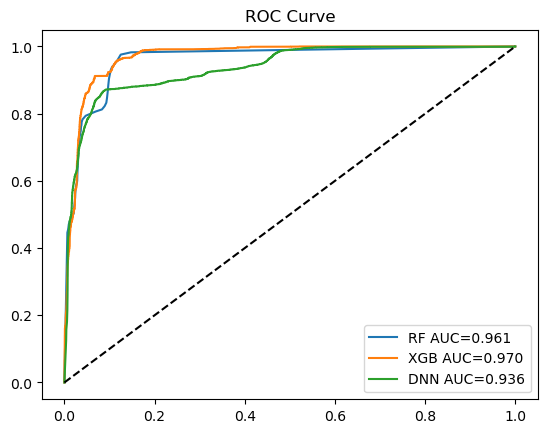

In [59]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
dnn_fpr, dnn_tpr, _ = roc_curve(y_test, dnn_prob)

rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)
dnn_auc = auc(dnn_fpr, dnn_tpr)

plt.plot(rf_fpr, rf_tpr, label=f"RF AUC={rf_auc:.3f}")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGB AUC={xgb_auc:.3f}")
plt.plot(dnn_fpr, dnn_tpr, label=f"DNN AUC={dnn_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()



- Confusion Matrix

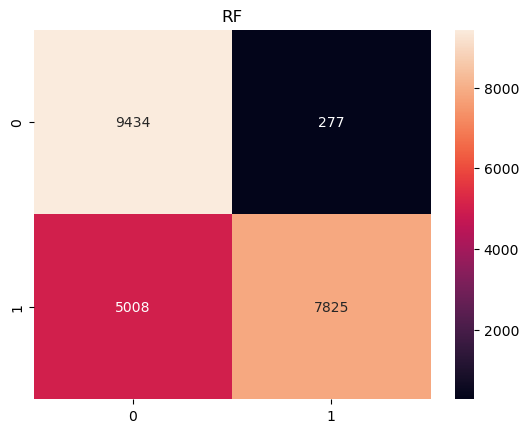

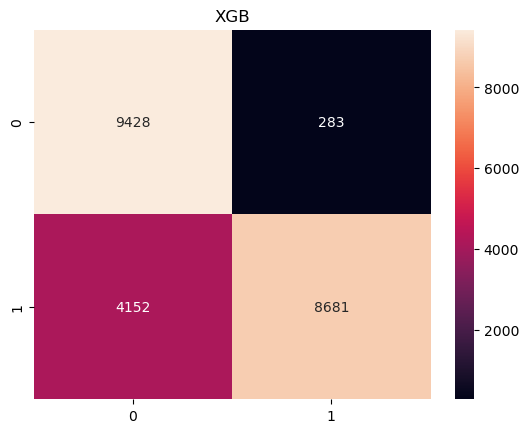

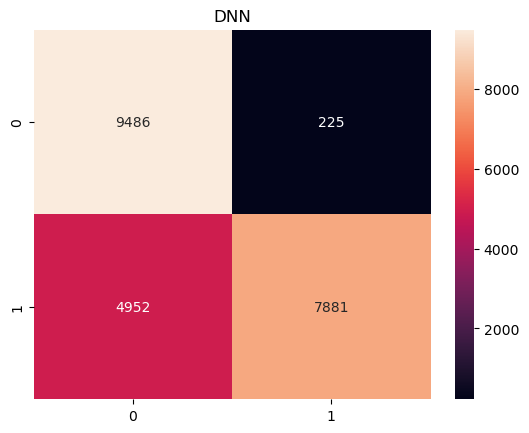

In [60]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.show()

plot_cm(y_test, rf_pred, "RF")
plot_cm(y_test, xgb_pred, "XGB")
plot_cm(y_test, dnn_pred, "DNN")



### Training and Validation Curve

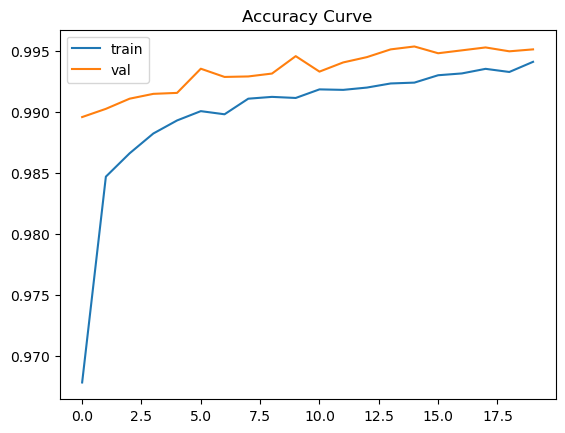

In [61]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

### Overfitting Analysis
 - If training accuracy is much higher than validation accuracy → Overfitting.
 - If both are low → Underfitting.
 - If both are high and similar → Good generalization.

### Loss Curve

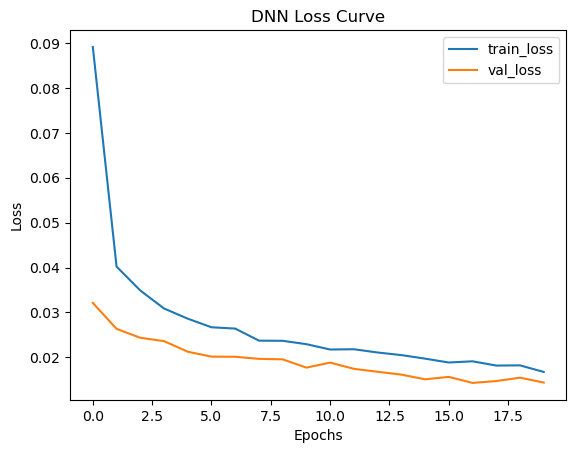

In [62]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("DNN Loss Curve")
plt.legend()
plt.show()

### COMPLEXITY ANALYSIS
 - Parameters & Time

In [63]:
rf_params = sum([tree.tree_.node_count for tree in rf.estimators_])
xgb_params = xgb_model.get_booster().num_boosted_rounds()
dnn_params = model.count_params()

# Inference time
start = time.time(); rf.predict(X_test); rf_inf = time.time()-start
start = time.time(); xgb_model.predict(X_test); xgb_inf = time.time()-start
start = time.time(); model.predict(X_test_scaled); dnn_inf = time.time()-start

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### Final Comparison Table

In [64]:
table = pd.DataFrame({
    "Model": ["RF", "XGB", "DNN"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, dnn_pred)
    ],
    "AUC": [rf_auc, xgb_auc, dnn_auc],
    "Parameters": [rf_params, xgb_params, dnn_params],
    "Train Time": [rf_time, xgb_time, dnn_time],
    "Inference Time": [rf_inf, xgb_inf, dnn_inf]
})

print(table)

  Model  Accuracy       AUC  Parameters  Train Time  Inference Time
0    RF  0.765570  0.960577      101296    6.013402        0.099113
1   XGB  0.803274  0.969853         200    4.906568        0.044873
2   DNN  0.770360  0.936224       16513   48.876369        2.122097


Among the evaluated models, XGBoost achieved the highest accuracy (80.3%) and AUC score (0.97), indicating superior classification and discrimination capability.

In addition, XGBoost demonstrated the lowest computational complexity with only 200 parameters, along with the fastest training and inference times.

Random Forest showed competitive performance but required significantly higher computational resources (100k+ parameters).

The Deep Neural Network exhibited lower performance and significantly higher training time, making it less suitable for tabular intrusion detection tasks.

Therefore, XGBoost is selected as the optimal model due to its superior performance, efficiency, and generalization ability.